In [ ]:
# Install yfinance library
!pip install yfinance --quiet

In [ ]:
# Import core libraries
import pandas as pd # for working w the data tabes
import matplotlib.pyplot as plt # for makign graphs
import yfinance as yf # for dw stock price data

In [ ]:
# dw Apple(aapl) stock data for the last 10 yrs
apple = yf.download('AAPL', period='10y')

# display the first 5 rows of the Dataframe
apple.head()

/tmp/ipykernel_23710/625012633.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  apple = yf.download('AAPL', period='10y')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-07,24.582191,25.007974,24.487070,24.901528,127207600
2016-04-08,24.609365,24.860757,24.498389,24.665986,94326800
2016-04-11,24.690897,25.051002,24.647867,24.679574,117630000
2016-04-12,25.012503,25.026091,24.609368,24.763373,108929200
2016-04-13,25.374868,25.442811,25.094033,25.094033,133029200


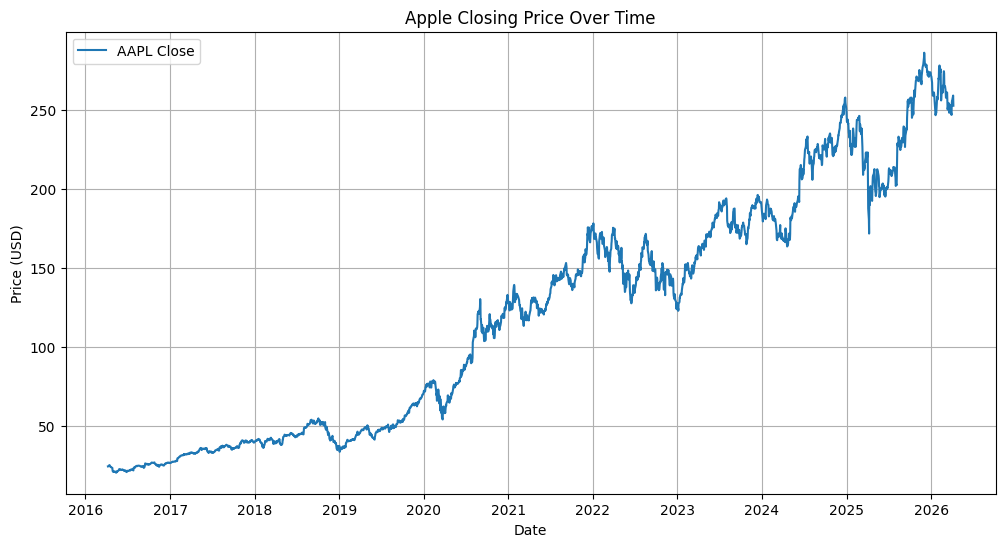

In [ ]:
# plot apple's closing price over time

plt.figure(figsize=(12,6)) # set size of plot
plt.plot(apple['Close'], label='AAPL Close') # draws line chart of daily closing prices
plt.title('Apple Closing Price Over Time') # chart title
plt.xlabel('Date') # x-axis label
plt.ylabel('Price (USD)') # y-axis label
plt.legend() # show legend-shows label we gave (appl close)
plt.grid(True) # show grid for easier reading
plt.show() # display the chart in a notebook

In [ ]:
# calc daily returns as % change
apple['Daily Return'] = apple['Close'].pct_change()

# show first 5 rows
apple.head()

Price,Close,High,Low,Open,Volume,Daily Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2016-04-07,24.582191,25.007974,24.487070,24.901528,127207600,NaN
2016-04-08,24.609365,24.860757,24.498389,24.665986,94326800,0.001105
2016-04-11,24.690897,25.051002,24.647867,24.679574,117630000,0.003313
2016-04-12,25.012503,25.026091,24.609368,24.763373,108929200,0.013025
2016-04-13,25.374868,25.442811,25.094033,25.094033,133029200,0.014487


In [ ]:
apple.columns

MultiIndex([(       'Close', 'AAPL'),
            (        'High', 'AAPL'),
            (         'Low', 'AAPL'),
            (        'Open', 'AAPL'),
            (      'Volume', 'AAPL'),
            ('Daily Return',     '')],
           names=['Price', 'Ticker'])

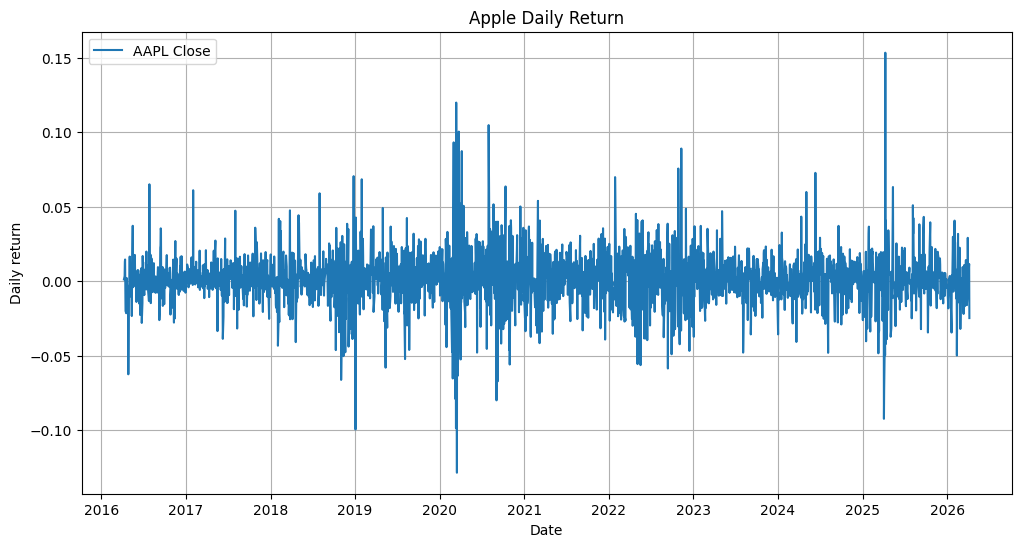

In [ ]:
# plot daily returns over time

plt.figure(figsize=(12,6)) # set size of plot
plt.plot(apple['Daily Return'], label='AAPL Close') # draws line chart of daily returns
plt.title('Apple Daily Return') # chart title
plt.xlabel('Date') # x-axis label
plt.ylabel('Daily return') # y-axis label
plt.legend() # show legend
plt.grid(True) # show grid for easier reading
plt.show() # display the chart in a notebook

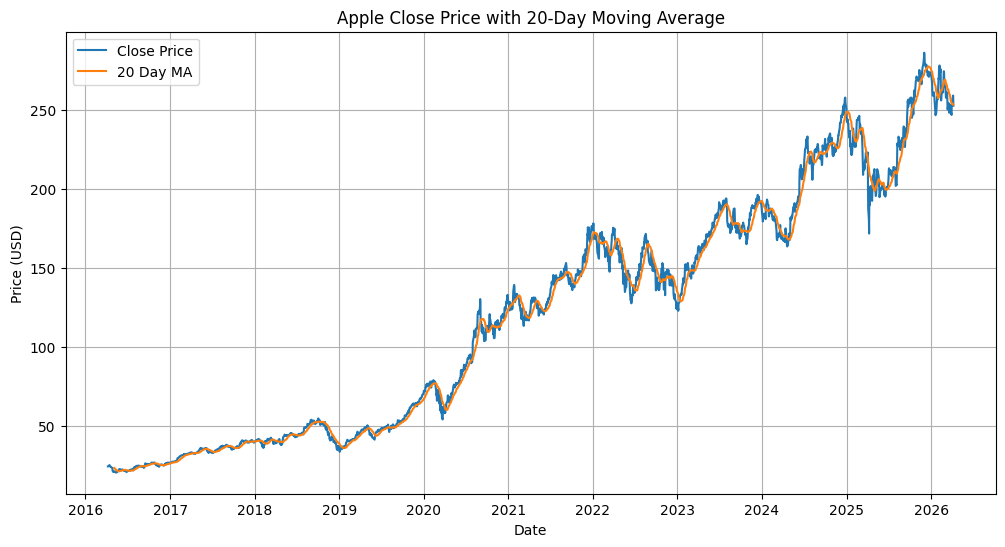

In [ ]:
# calculate 20 day moving avg of closing price
apple['20 Day MA'] = apple['Close'].rolling(window=20).mean()

# plot the closing price and 20 day moving avg

plt.figure(figsize=(12,6)) # set size of plot
plt.plot(apple['Close'], label='Close Price') # actual close price
plt.plot(apple['20 Day MA'], label='20 Day MA') # 20 day moving avg
plt.title('Apple Close Price with 20-Day Moving Average') # chart title
plt.xlabel('Date') # x-axis label
plt.ylabel('Price (USD)') # y-axis label
plt.legend() # show legend-shows label we gave (appl close)
plt.grid(True) # show grid for easier reading
plt.show() # display the chart in a notebook

In [ ]:
# dw jp morgan (jpm) stock data for last 10 yrs
import yfinance as yf

jpm = yf.download('JPM', period='10y')

# keep only the 'close' coloumn for prediction
jpm_close = jpm[['Close']]

/tmp/ipykernel_23710/3746366711.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  jpm = yf.download('JPM', period='10y')
[*********************100%***********************]  1 of 1 completed


In [ ]:
# normalise data for LSTM (values between 0 and 1)
from sklearn.preprocessing import MinMaxScaler

scaler_apple = MinMaxScaler(feature_range=(0,1))
scaler_jpm = MinMaxScaler(feature_range=(0,1))

# scale apple and jpm closing prices
apple_scaled = scaler_apple.fit_transform(apple[['Close']])
jpm_scaled = scaler_jpm.fit_transform(jpm_close)

In [ ]:
import numpy as np

# function to create sequences for LSTM
def create_sequences(data, seq_length=60):
  X, y = [], []
  for i in range(seq_length, len(data)):
    X.append(data[i-seq_length:i, 0])
    y.append(data[i, 0])
  return np.array(X), np.array(y)

# apple sequences
X_apple, y_apple = create_sequences(apple_scaled)
# jp  morgan sequences
X_jpm, y_jpm = create_sequences(jpm_scaled)

# reshape to 3d for LSTM [samples, timesteps, features]
X_apple = X_apple.reshape(X_apple.shape[0], X_apple.shape[1], 1)
X_jpm = X_jpm.reshape(X_jpm.shape[0], X_jpm.shape[1], 1)



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input

def build_lstm():
  model = Sequential()
  model.add(Input(shape=(60,1)))
  model.add(LSTM(units=50, return_sequences=True))
  model.add(Dropout(0.2))
  model.add(LSTM(units=50))
  model.add(Dropout(0.2))
  model.add(Dense(1))
  model.compile(optimizer='adam', loss='mean_squared_error')
  return model

# build models for apple and jpm
model_apple = build_lstm()
model_jpm = build_lstm()

In [ ]:

# train apple lstm
model_apple.fit(X_apple, y_apple, epochs=5, batch_size=32, verbose=1)

# train jpm lstm
model_jpm.fit(X_jpm, y_jpm, epochs=5, batch_size=32, verbose=1)

Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - loss: 0.0157
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0025
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.0023
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.0021
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0020
Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - loss: 0.0079
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0019
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0016
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 0.0017
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0014


In [ ]:
# predict
pred_apple = model_apple.predict(X_apple)
pred_jpm = model_jpm.predict(X_jpm)

# inverse scaling to get actual prices
pred_apple = scaler_apple.inverse_transform(pred_apple)
pred_jpm = scaler_jpm.inverse_transform(pred_jpm)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


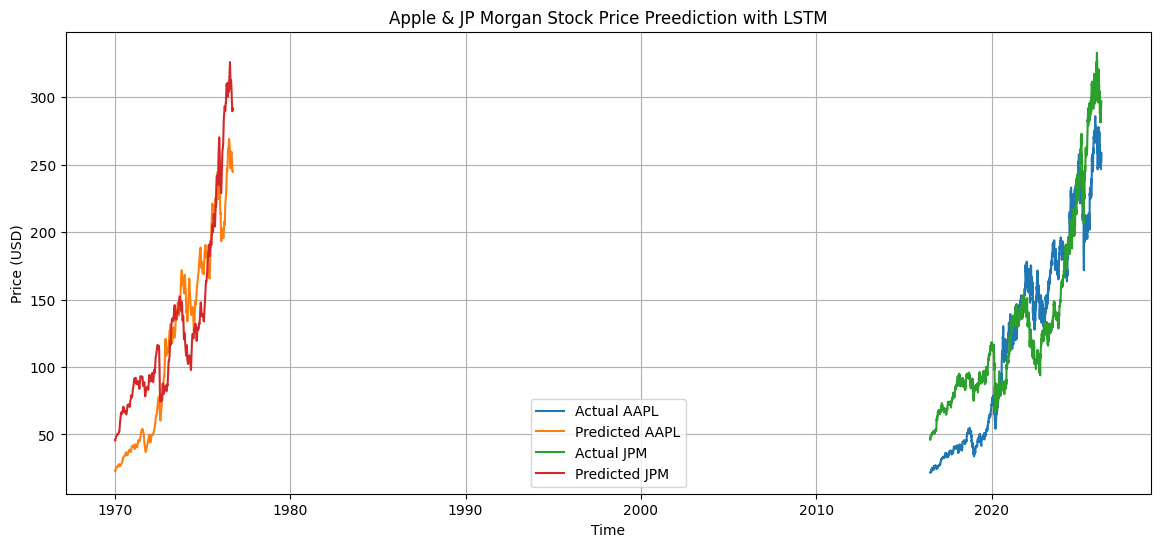

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# apple actual vs predicted
plt.plot(apple['Close'][60:], label='Actual AAPL')
plt.plot(pred_apple, label='Predicted AAPL')

# jpm actual vs predicted
plt.plot(jpm['Close'][60:], label='Actual JPM')
plt.plot(pred_jpm, label='Predicted JPM')

plt.title('Apple & JP Morgan Stock Price Preediction with LSTM')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

dataset = apple['Close'].values
dataset = dataset.reshape(-1,1)  # make it 2D for the scaler

scaler_apple = MinMaxScaler(feature_range=(0,1))
scaled_data_apple = scaler_apple.fit_transform(dataset)

In [ ]:
dataset = jpm['Close'].values
dataset = dataset.reshape(-1,1)

scaler_jpm = MinMaxScaler(feature_range=(0,1))
scaled_data_jpm = scaler_jpm.fit_transform(dataset)

In [ ]:
X_test_apple = []
y_test_apple = []

for i in range(60, len(scaled_data_apple)):
    X_test_apple.append(scaled_data_apple[i-60:i, 0])
    y_test_apple.append(scaled_data_apple[i, 0])

X_test_apple, y_test_apple = np.array(X_test_apple), np.array(y_test_apple)
X_test_apple = X_test_apple.reshape((X_test_apple.shape[0], X_test_apple.shape[1], 1))

In [ ]:
X_test_jpm = []
y_test_jpm = []

for i in range(60, len(scaled_data_jpm)):
    X_test_jpm.append(scaled_data_jpm[i-60:i, 0])
    y_test_jpm.append(scaled_data_jpm[i, 0])

X_test_jpm, y_test_jpm = np.array(X_test_jpm), np.array(y_test_jpm)
X_test_jpm = X_test_jpm.reshape((X_test_jpm.shape[0], X_test_jpm.shape[1], 1))

In [ ]:
dataset = apple['Close'].values
dataset = dataset.reshape(-1,1)

# Split into training and test sets
train_size = int(len(dataset) * 0.8)
train_data = dataset[:train_size]
test_data  = dataset[train_size-60:]  # include last 60 for sequences

# Create X_test and y_test
X_test_apple = []
y_test_apple = []

for i in range(60, len(test_data)):
    X_test_apple.append(test_data[i-60:i, 0])
    y_test_apple.append(test_data[i, 0])

X_test_apple, y_test_apple = np.array(X_test_apple), np.array(y_test_apple)
X_test_apple = X_test_apple.reshape((X_test_apple.shape[0], X_test_apple.shape[1], 1))

In [ ]:
dataset = jpm['Close'].values
dataset = dataset.reshape(-1,1)

train_size = int(len(dataset) * 0.8)
train_data = dataset[:train_size]
test_data  = dataset[train_size-60:]

X_test_jpm = []
y_test_jpm = []

for i in range(60, len(test_data)):
    X_test_jpm.append(test_data[i-60:i, 0])
    y_test_jpm.append(test_data[i, 0])

X_test_jpm, y_test_jpm = np.array(X_test_jpm), np.array(y_test_jpm)
X_test_jpm = X_test_jpm.reshape((X_test_jpm.shape[0], X_test_jpm.shape[1], 1))

In [ ]:
# Predict on test data
y_pred_apple = model_apple.predict(X_test_apple)
y_pred_jpm   = model_jpm.predict(X_test_jpm)

# If you scaled the data, inverse-transform to get actual prices
y_pred_apple = scaler_apple.inverse_transform(y_pred_apple)
y_test_apple = scaler_apple.inverse_transform(y_test_apple)

y_pred_jpm = scaler_jpm.inverse_transform(y_pred_jpm)
y_test_jpm = scaler_jpm.inverse_transform(y_test_jpm)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


ValueError: Expected 2D array, got 1D array instead:
array=[167.29745483 168.05059814 166.93078613 168.13978577 166.26681519
 173.46134949 174.95773315 171.1325531  167.85240173 166.48483276
 165.53349304 163.5118866  164.34431458 165.39477539 167.49565125
 168.3578186  167.77311707 171.9352417  168.79385376 167.77311707
 171.46948242 181.72616577 180.07119751 180.75497437 181.09188843
 182.90541077 181.6451416  184.85037231 185.99153137 188.26397705
 188.38304138 188.41281128 189.57383728 190.87379456 189.43490601
 185.44577026 188.52197266 188.53189087 188.8296051  189.82189941
 190.77455139 192.54089355 192.85844421 194.36677551 192.98744202
 195.37893677 191.6378479  205.56018066 211.43476868 212.59576416
 210.85923767 215.00714111 212.645401   208.07077026 205.89758301
 206.54257202 207.4654541  211.61338806 212.4568634  209.00357056
 215.08651733 218.57949829 219.84968567 224.60292053 226.07156372
 226.92495728 231.19194031 225.82348633 228.77069092 232.60105896
 233.01786804 227

In [ ]:
# Install yfinance library
!pip install yfinance --quiet

# Import core libraries
import pandas as pd # for working w the data tabes
import matplotlib.pyplot as plt # for makign graphs
import yfinance as yf # for dw stock price data

# dw Apple(aapl) stock data for the last 10 yrs
apple = yf.download('AAPL', period='10y')

# display the first 5 rows of the Dataframe
apple.head()

# plot apple's closing price over time

plt.figure(figsize=(12,6)) # set size of plot
plt.plot(apple['Close'], label='AAPL Close') # draws line chart of daily closing prices
plt.title('Apple Closing Price Over Time') # chart title
plt.xlabel('Date') # x-axis label
plt.ylabel('Price (USD)') # y-axis label
plt.legend() # show legend-shows label we gave (appl close)
plt.grid(True) # show grid for easier reading
plt.show() # display the chart in a notebook

# calc daily returns as % change
apple['Daily Return'] = apple['Close'].pct_change()

# show first 5 rows
apple.head()

# plot daily returns over time

plt.figure(figsize=(12,6)) # set size of plot
plt.plot(apple['Daily Return'], label='AAPL Close') # draws line chart of daily returns
plt.title('Apple Daily Return') # chart title
plt.xlabel('Date') # x-axis label
plt.ylabel('Daily return') # y-axis label
plt.legend() # show legend
plt.grid(True) # show grid for easier reading
plt.show() # display the chart in a notebook

# calculate 20 day moving avg of closing price
apple['20 Day MA'] = apple['Close'].rolling(window=20).mean()

# plot the closing price and 20 day moving avg

plt.figure(figsize=(12,6)) # set size of plot
plt.plot(apple['Close'], label='Close Price') # actual close price
plt.plot(apple['20 Day MA'], label='20 Day MA') # 20 day moving avg
plt.title('Apple Close Price with 20-Day Moving Average') # chart title
plt.xlabel('Date') # x-axis label
plt.ylabel('Price (USD)') # y-axis label
plt.legend() # show legend-shows label we gave (appl close)
plt.grid(True) # show grid for easier reading
plt.show() # display the chart in a notebook

# dw jp morgan (jpm) stock data for last 10 yrs
import yfinance as yf

jpm = yf.download('JPM', period='10y')

# keep only the 'close' coloumn for prediction
jpm_close = jpm[['Close']]

# normalise data for LSTM (values between 0 and 1)
from sklearn.preprocessing import MinMaxScaler

scaler_apple = MinMaxScaler(feature_range=(0,1))
scaler_jpm = MinMaxScaler(feature_range=(0,1))

# scale apple and jpm closing prices
apple_scaled = scaler_apple.fit_transform(apple[['Close']])
jpm_scaled = scaler_jpm.fit_transform(jpm_close)

import numpy as np

# function to create sequences for LSTM
def create_sequences(data, seq_length=60):
  X, y = [], []
  for i in range(seq_length, len(data)):
    X.append(data[i-seq_length:i, 0])
    y.append(data[i, 0])
  return np.array(X), np.array(y)

# apple sequences
X_apple, y_apple = create_sequences(apple_scaled)
# jp  morgan sequences
X_jpm, y_jpm = create_sequences(jpm_scaled)

# reshape to 3d for LSTM [samples, timesteps, features]
X_apple = X_apple.reshape(X_apple.shape[0], X_apple.shape[1], 1)
X_jpm = X_jpm.reshape(X_jpm.shape[0], X_jpm.shape[1], 1)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input

def build_lstm():
  model = Sequential()
  model.add(Input(shape=(60,1)))
  model.add(LSTM(units=50, return_sequences=True))
  model.add(Dropout(0.2))
  model.add(LSTM(units=50))
  model.add(Dropout(0.2))
  model.add(Dense(1))
  model.compile(optimizer='adam', loss='mean_squared_error')
  return model

# build models for apple and jpm
model_apple = build_lstm()
model_jpm = build_lstm()

# train apple lstm
model_apple.fit(X_apple, y_apple, epochs=5, batch_size=32, verbose=1)

# train jpm lstm
model_jpm.fit(X_jpm, y_jpm, epochs=5, batch_size=32, verbose=1)

# predict
pred_apple = model_apple.predict(X_apple)
pred_jpm = model_jpm.predict(X_jpm)

# inverse scaling to get actual prices
pred_apple = scaler_apple.inverse_transform(pred_apple)
pred_jpm = scaler_jpm.inverse_transform(pred_jpm)

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# apple actual vs predicted
plt.plot(apple['Close'][60:], label='Actual AAPL')
plt.plot(pred_apple, label='Predicted AAPL')

# jpm actual vs predicted
plt.plot(jpm['Close'][60:], label='Actual JPM')
plt.plot(pred_jpm, label='Predicted JPM')

plt.title('Apple & JP Morgan Stock Price Preediction with LSTM')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

from sklearn.preprocessing import MinMaxScaler
import numpy as np

dataset = apple['Close'].values
dataset = dataset.reshape(-1,1)  # make it 2D for the scaler

scaler_apple = MinMaxScaler(feature_range=(0,1))
scaled_data_apple = scaler_apple.fit_transform(dataset)

dataset = jpm['Close'].values
dataset = dataset.reshape(-1,1)

scaler_jpm = MinMaxScaler(feature_range=(0,1))
scaled_data_jpm = scaler_jpm.fit_transform(dataset)

X_test_apple = []
y_test_apple = []

for i in range(60, len(scaled_data_apple)):
    X_test_apple.append(scaled_data_apple[i-60:i, 0])
    y_test_apple.append(scaled_data_apple[i, 0])

X_test_apple, y_test_apple = np.array(X_test_apple), np.array(y_test_apple)
X_test_apple = X_test_apple.reshape((X_test_apple.shape[0], X_test_apple.shape[1], 1))

X_test_jpm = []
y_test_jpm = []

for i in range(60, len(scaled_data_jpm)):
    X_test_jpm.append(scaled_data_jpm[i-60:i, 0])
    y_test_jpm.append(scaled_data_jpm[i, 0])

X_test_jpm, y_test_jpm = np.array(X_test_jpm), np.array(y_test_jpm)
X_test_jpm = X_test_jpm.reshape((X_test_jpm.shape[0], X_test_jpm.shape[1], 1))

dataset = apple['Close'].values
dataset = dataset.reshape(-1,1)

# Split into training and test sets
train_size = int(len(dataset) * 0.8)
train_data = dataset[:train_size]
test_data  = dataset[train_size-60:]  # include last 60 for sequences

# Create X_test and y_test
X_test_apple = []
y_test_apple = []

for i in range(60, len(test_data)):
    X_test_apple.append(test_data[i-60:i, 0])
    y_test_apple.append(test_data[i, 0])

X_test_apple, y_test_apple = np.array(X_test_apple), np.array(y_test_apple)
X_test_apple = X_test_apple.reshape((X_test_apple.shape[0], X_test_apple.shape[1], 1))

dataset = jpm['Close'].values
dataset = dataset.reshape(-1,1)

train_size = int(len(dataset) * 0.8)
train_data = dataset[:train_size]
test_data  = dataset[train_size-60:]

X_test_jpm = []
y_test_jpm = []

for i in range(60, len(test_data)):
    X_test_jpm.append(test_data[i-60:i, 0])
    y_test_jpm.append(test_data[i, 0])

X_test_jpm, y_test_jpm = np.array(X_test_jpm), np.array(y_test_jpm)
X_test_jpm = X_test_jpm.reshape((X_test_jpm.shape[0], X_test_jpm.shape[1], 1))

# Predict on test data
y_pred_apple = model_apple.predict(X_test_apple)
y_pred_jpm   = model_jpm.predict(X_test_jpm)

# If you scaled the data, inverse-transform to get actual prices
y_pred_apple = scaler_apple.inverse_transform(y_pred_apple)
y_test_apple = scaler_apple.inverse_transform(y_test_apple)

y_pred_jpm = scaler_jpm.inverse_transform(y_pred_jpm)
y_test_jpm = scaler_jpm.inverse_transform(y_test_jpm)

In [ ]:
# Install yfinance library
!pip install yfinance --quiet

# Import core libraries
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input

# Download stock data (10 years)
apple = yf.download('AAPL', period='10y')
jpm   = yf.download('JPM', period='10y')

# Scale the closing prices
scaler_apple = MinMaxScaler(feature_range=(0,1))
scaler_jpm   = MinMaxScaler(feature_range=(0,1))

apple_scaled = scaler_apple.fit_transform(apple[['Close']])
jpm_scaled   = scaler_jpm.fit_transform(jpm[['Close']])

# Function to create sequences for LSTM
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Apple sequences
X_apple, y_apple = create_sequences(apple_scaled)
# JPM sequences
X_jpm, y_jpm = create_sequences(jpm_scaled)

# Reshape to 3D for LSTM
X_apple = X_apple.reshape(X_apple.shape[0], X_apple.shape[1], 1)
X_jpm   = X_jpm.reshape(X_jpm.shape[0], X_jpm.shape[1], 1)

# Build LSTM model
def build_lstm():
    model = Sequential()
    model.add(Input(shape=(60,1)))
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Train models
model_apple = build_lstm()
model_jpm   = build_lstm()

model_apple.fit(X_apple, y_apple, epochs=5, batch_size=32, verbose=1)
model_jpm.fit(X_jpm, y_jpm, epochs=5, batch_size=32, verbose=1)

# Predict
pred_apple = model_apple.predict(X_apple)
pred_jpm   = model_jpm.predict(X_jpm)

# Inverse transform to actual prices
pred_apple = scaler_apple.inverse_transform(pred_apple)
pred_jpm   = scaler_jpm.inverse_transform(pred_jpm)

# Align predictions with actual dates instead of row index
dates_apple = apple.index[60:]
dates_jpm   = jpm.index[60:]

plt.figure(figsize=(14,6))

# Apple actual vs predicted
plt.plot(dates_apple, apple['Close'][60:].values, label='Actual AAPL')
plt.plot(dates_apple, pred_apple, label='Predicted AAPL')

# JPM actual vs predicted
plt.plot(dates_jpm, jpm['Close'][60:].values, label='Actual JPM')
plt.plot(dates_jpm, pred_jpm, label='Predicted JPM')

plt.title('Apple & JP Morgan Stock Price Prediction with LSTM')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# Accuracy (RMSE)

from sklearn.metrics import mean_squared_error
import math

rmse_apple = math.sqrt(mean_squared_error(apple['Close'][60:], pred_apple))
rmse_jpm   = math.sqrt(mean_squared_error(jpm['Close'][60:], pred_jpm))

print(f"RMSE Apple: {rmse_apple:.2f}")
print(f"RMSE JPM: {rmse_jpm:.2f}")

# Simulated trading returns

def simulated_returns(actual, predicted):
    actual = actual.flatten()
    predicted = predicted.flatten()
    daily_returns = np.diff(actual)/actual[:-1]
    strategy_returns = []

    for i in range(len(daily_returns)):
        # simple strategy: buy if predicted price increases from previous day
        if predicted[i+1] > predicted[i]:  # shift by 1 to align
            strategy_returns.append(daily_returns[i])
        else:
            strategy_returns.append(0)

    strategy_returns = np.array(strategy_returns)
    cumulative_strategy = np.cumprod(1 + strategy_returns)
    cumulative_actual   = np.cumprod(1 + daily_returns)
    return cumulative_actual, cumulative_strategy

cum_actual_apple, cum_strategy_apple = simulated_returns(apple['Close'][60:].values, pred_apple)
cum_actual_jpm, cum_strategy_jpm     = simulated_returns(jpm['Close'][60:].values, pred_jpm)

# Plot simulated returns
plt.figure(figsize=(12,5))
plt.plot(cum_actual_apple, label='Apple Actual Cumulative Return', color='blue')
plt.plot(cum_strategy_apple, label='Apple Strategy Return', color='cyan')
plt.plot(cum_actual_jpm, label='JPM Actual Cumulative Return', color='red')
plt.plot(cum_strategy_jpm, label='JPM Strategy Return', color='orange')
plt.legend()
plt.title('Simulated Investment Returns (Apple & JPM)')
plt.show()

# Forecast 1 year into the future (~252 trading days)

def forecast_future(model, last_60_scaled, scaler, steps=252):
    future_preds = []
    current_batch = last_60_scaled.reshape((1, 60, 1))

    for _ in range(steps):
        pred = model.predict(current_batch, verbose=0)[0]
        future_preds.append(pred)
        current_batch = np.append(current_batch[:,1:,:], [[pred]], axis=1)

    future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))
    return future_preds

# get last 60 scaled values
last_60_apple = apple_scaled[-60:]
last_60_jpm   = jpm_scaled[-60:]

future_apple = forecast_future(model_apple, last_60_apple, scaler_apple)
future_jpm   = forecast_future(model_jpm, last_60_jpm, scaler_jpm)

# create future dates
import pandas as pd
last_date_apple = apple.index[-1]
last_date_jpm   = jpm.index[-1]

future_dates_apple = pd.date_range(last_date_apple + pd.Timedelta(days=1), periods=252, freq='B')
future_dates_jpm   = pd.date_range(last_date_jpm + pd.Timedelta(days=1), periods=252, freq='B')


# Plot future forecast

plt.figure(figsize=(14,6))
plt.plot(apple.index, apple['Close'], label='Apple Actual', color='blue')
plt.plot(future_dates_apple, future_apple, label='Apple Forecast', color='cyan', linestyle='--')
plt.legend()
plt.title('Apple Stock Price Forecast (Next 1 Year)')
plt.show()

plt.figure(figsize=(14,6))
plt.plot(jpm.index, jpm['Close'], label='JPM Actual', color='red')
plt.plot(future_dates_jpm, future_jpm, label='JPM Forecast', color='orange', linestyle='--')
plt.legend()
plt.title('JPM Stock Price Forecast (Next 1 Year)')
plt.show()


# Forecast 1 & 2 years ahead

def forecast_future(model, last_60_scaled, scaler, steps):
    future_preds = []
    current_batch = last_60_scaled.reshape((1, 60, 1))
    for _ in range(steps):
        pred = model.predict(current_batch, verbose=0)[0]
        future_preds.append(pred)
        current_batch = np.append(current_batch[:,1:,:], [[pred]], axis=1)
    future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))
    return future_preds

# Last 60 scaled values
last_60_apple = apple_scaled[-60:]
last_60_jpm   = jpm_scaled[-60:]

# 252 trading days per year
future_1y_apple = forecast_future(model_apple, last_60_apple, scaler_apple, steps=252)
future_2y_apple = forecast_future(model_apple, last_60_apple, scaler_apple, steps=504)

future_1y_jpm = forecast_future(model_jpm, last_60_jpm, scaler_jpm, steps=252)
future_2y_jpm = forecast_future(model_jpm, last_60_jpm, scaler_jpm, steps=504)

# Create future dates

last_date_apple = apple.index[-1]
last_date_jpm   = jpm.index[-1]

future_dates_1y_apple = pd.date_range(last_date_apple + pd.Timedelta(days=1), periods=252, freq='B')
future_dates_2y_apple = pd.date_range(last_date_apple + pd.Timedelta(days=1), periods=504, freq='B')

future_dates_1y_jpm = pd.date_range(last_date_jpm + pd.Timedelta(days=1), periods=252, freq='B')
future_dates_2y_jpm = pd.date_range(last_date_jpm + pd.Timedelta(days=1), periods=504, freq='B')

# Side-by-side plotting

fig, axs = plt.subplots(2, 1, figsize=(16,10), sharex=False)

# Apple
axs[0].plot(apple.index, apple['Close'], label='Actual', color='blue')
axs[0].plot(future_dates_1y_apple, future_1y_apple, label='1-Year Forecast', color='cyan', linestyle='--')
axs[0].plot(future_dates_2y_apple, future_2y_apple, label='2-Year Forecast', color='green', linestyle='--')
axs[0].set_title('Apple Stock Price Forecast')
axs[0].set_ylabel('Price (USD)')
axs[0].legend()
axs[0].grid(True)

# JPM
axs[1].plot(jpm.index, jpm['Close'], label='Actual', color='red')
axs[1].plot(future_dates_1y_jpm, future_1y_jpm, label='1-Year Forecast', color='orange', linestyle='--')
axs[1].plot(future_dates_2y_jpm, future_2y_jpm, label='2-Year Forecast', color='purple', linestyle='--')
axs[1].set_title('JPM Stock Price Forecast')
axs[1].set_ylabel('Price (USD)')
axs[1].legend()
axs[1].grid(True)

plt.show()

In [ ]:
# Install yfinance
!pip install yfinance --quiet

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input

# Download stock data (last 10 years)
apple = yf.download('AAPL', period='10y')
jpm   = yf.download('JPM', period='10y')

# Scale closing prices
scaler_apple = MinMaxScaler(feature_range=(0,1))
scaler_jpm   = MinMaxScaler(feature_range=(0,1))

apple_scaled = scaler_apple.fit_transform(apple[['Close']])
jpm_scaled   = scaler_jpm.fit_transform(jpm[['Close']])

# Create sequences for LSTM
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_apple, y_apple = create_sequences(apple_scaled)
X_jpm, y_jpm     = create_sequences(jpm_scaled)

# Reshape to 3D for LSTM [samples, timesteps, features]
X_apple = X_apple.reshape(X_apple.shape[0], X_apple.shape[1], 1)
X_jpm   = X_jpm.reshape(X_jpm.shape[0], X_jpm.shape[1], 1)

# Build LSTM model function
def build_lstm():
    model = Sequential()
    model.add(Input(shape=(60,1)))
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Train models
model_apple = build_lstm()
model_jpm   = build_lstm()

model_apple.fit(X_apple, y_apple, epochs=5, batch_size=32, verbose=1)
model_jpm.fit(X_jpm, y_jpm, epochs=5, batch_size=32, verbose=1)

# Predict on training data
pred_apple = model_apple.predict(X_apple)
pred_jpm   = model_jpm.predict(X_jpm)

# Inverse scaling to get actual prices
pred_apple = scaler_apple.inverse_transform(pred_apple)
pred_jpm   = scaler_jpm.inverse_transform(pred_jpm)

dates_apple = apple.index[60:]
dates_jpm   = jpm.index[60:]

# Performance metrics
pred_apple_flat = pred_apple.flatten()
pred_jpm_flat   = pred_jpm.flatten()

rmse_apple = math.sqrt(mean_squared_error(apple['Close'][60:], pred_apple_flat))
rmse_jpm   = math.sqrt(mean_squared_error(jpm['Close'][60:], pred_jpm_flat))

mape_apple = np.mean(np.abs((apple['Close'][60:].values - pred_apple_flat) / apple['Close'][60:].values)) * 100
mape_jpm   = np.mean(np.abs((jpm['Close'][60:].values - pred_jpm_flat) / jpm['Close'][60:].values)) * 100

print(f"Apple RMSE: {rmse_apple:.2f}, MAPE: {mape_apple:.2f}%")
print(f"JPM RMSE: {rmse_jpm:.2f}, MAPE: {mape_jpm:.2f}%")

# Simulated returns
def simulated_returns(actual, predicted):
    actual = actual.flatten()
    predicted = predicted.flatten()
    daily_returns = np.diff(actual)/actual[:-1]
    strategy_returns = []
    for i in range(len(daily_returns)):
        if predicted[i+1] > predicted[i]:
            strategy_returns.append(daily_returns[i])
        else:
            strategy_returns.append(0)
    strategy_returns = np.array(strategy_returns)
    cumulative_strategy = np.cumprod(1 + strategy_returns)
    cumulative_actual   = np.cumprod(1 + daily_returns)
    return cumulative_actual, cumulative_strategy

cum_actual_apple, cum_strategy_apple = simulated_returns(apple['Close'][60:].values, pred_apple)
cum_actual_jpm, cum_strategy_jpm     = simulated_returns(jpm['Close'][60:].values, pred_jpm)

# Forecast future prices
def forecast_future(model, last_60_scaled, scaler, steps):
    future_preds = []
    current_batch = last_60_scaled.reshape((1, 60, 1))
    for _ in range(steps):
        pred = model.predict(current_batch, verbose=0)[0]
        future_preds.append(pred)
        current_batch = np.append(current_batch[:,1:,:], [[pred]], axis=1)
    future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))
    return future_preds

# Last 60 scaled values
last_60_apple = apple_scaled[-60:]
last_60_jpm   = jpm_scaled[-60:]

# Forecast 1-year & 2-year (252 trading days per year)
future_1y_apple = forecast_future(model_apple, last_60_apple, scaler_apple, 252)
future_2y_apple = forecast_future(model_apple, last_60_apple, scaler_apple, 504)

future_1y_jpm = forecast_future(model_jpm, last_60_jpm, scaler_jpm, 252)
future_2y_jpm = forecast_future(model_jpm, last_60_jpm, scaler_jpm, 504)

# Future dates
future_dates_1y_apple = pd.date_range(apple.index[-1] + pd.Timedelta(days=1), periods=252, freq='B')
future_dates_2y_apple = pd.date_range(apple.index[-1] + pd.Timedelta(days=1), periods=504, freq='B')

future_dates_1y_jpm = pd.date_range(jpm.index[-1] + pd.Timedelta(days=1), periods=252, freq='B')
future_dates_2y_jpm = pd.date_range(jpm.index[-1] + pd.Timedelta(days=1), periods=504, freq='B')

# Side-by-side plotting
fig, axs = plt.subplots(2, 1, figsize=(16,10), sharex=False)

# Apple
axs[0].plot(apple.index, apple['Close'], label='Actual', color='blue')
axs[0].plot(future_dates_1y_apple, future_1y_apple, label='1-Year Forecast', color='cyan', linestyle='--')
axs[0].plot(future_dates_2y_apple, future_2y_apple, label='2-Year Forecast', color='green', linestyle='--')
axs[0].plot(dates_apple[1:], cum_strategy_apple * apple['Close'][60], label='Strategy Cumulative', color='orange', alpha=0.6)
axs[0].set_title('Apple Stock Price & Strategy Forecast')
axs[0].set_ylabel('Price (USD)')
axs[0].legend()
axs[0].grid(True)

# JPM
axs[1].plot(jpm.index, jpm['Close'], label='Actual', color='red')
axs[1].plot(future_dates_1y_jpm, future_1y_jpm, label='1-Year Forecast', color='orange', linestyle='--')
axs[1].plot(future_dates_2y_jpm, future_2y_jpm, label='2-Year Forecast', color='purple', linestyle='--')
axs[1].plot(dates_jpm[1:], cum_strategy_jpm * jpm['Close'][60], label='Strategy Cumulative', color='cyan', alpha=0.6)
axs[1].set_title('JPM Stock Price & Strategy Forecast')
axs[1].set_ylabel('Price (USD)')
axs[1].legend()
axs[1].grid(True)

In [ ]:
# Install yfinance library
!pip install yfinance --quiet

# Import core libraries
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input

# Download stock data (10 years)
apple = yf.download('AAPL', period='10y')
jpm   = yf.download('JPM', period='10y')

# Scale the closing prices
scaler_apple = MinMaxScaler(feature_range=(0,1))
scaler_jpm   = MinMaxScaler(feature_range=(0,1))

apple_scaled = scaler_apple.fit_transform(apple[['Close']])
jpm_scaled   = scaler_jpm.fit_transform(jpm[['Close']])

# Function to create sequences for LSTM
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Apple sequences
X_apple, y_apple = create_sequences(apple_scaled)
# JPM sequences
X_jpm, y_jpm = create_sequences(jpm_scaled)

# Reshape to 3D for LSTM
X_apple = X_apple.reshape(X_apple.shape[0], X_apple.shape[1], 1)
X_jpm   = X_jpm.reshape(X_jpm.shape[0], X_jpm.shape[1], 1)

# Build LSTM model
def build_lstm():
    model = Sequential()
    model.add(Input(shape=(60,1)))
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Train models
model_apple = build_lstm()
model_jpm   = build_lstm()

model_apple.fit(X_apple, y_apple, epochs=5, batch_size=32, verbose=1)
model_jpm.fit(X_jpm, y_jpm, epochs=5, batch_size=32, verbose=1)

# Predict
pred_apple = model_apple.predict(X_apple)
pred_jpm   = model_jpm.predict(X_jpm)

# Inverse transform to actual prices
pred_apple = scaler_apple.inverse_transform(pred_apple)
pred_jpm   = scaler_jpm.inverse_transform(pred_jpm)

# Align predictions with actual dates using iloc
dates_apple = apple.index[60:]
dates_jpm   = jpm.index[60:]

plt.figure(figsize=(14,6))
plt.plot(dates_apple, apple['Close'].iloc[60:].values, label='Actual AAPL')
plt.plot(dates_apple, pred_apple, label='Predicted AAPL')
plt.plot(dates_jpm, jpm['Close'].iloc[60:].values, label='Actual JPM')
plt.plot(dates_jpm, pred_jpm, label='Predicted JPM')
plt.title('Apple & JP Morgan Stock Price Prediction with LSTM')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# RMSE
from sklearn.metrics import mean_squared_error
import math

rmse_apple = math.sqrt(mean_squared_error(apple['Close'].iloc[60:], pred_apple))
rmse_jpm   = math.sqrt(mean_squared_error(jpm['Close'].iloc[60:], pred_jpm))

print(f"RMSE Apple: {rmse_apple:.2f}")
print(f"RMSE JPM: {rmse_jpm:.2f}")

# Simulated trading returns
def simulated_returns(actual, predicted):
    actual = actual.flatten()
    predicted = predicted.flatten()
    daily_returns = np.diff(actual)/actual[:-1]
    strategy_returns = []
    for i in range(len(daily_returns)):
        if predicted[i+1] > predicted[i]:  # shift by 1 to align
            strategy_returns.append(daily_returns[i])
        else:
            strategy_returns.append(0)
    strategy_returns = np.array(strategy_returns)
    cumulative_strategy = np.cumprod(1 + strategy_returns)
    cumulative_actual   = np.cumprod(1 + daily_returns)
    return cumulative_actual, cumulative_strategy

cum_actual_apple, cum_strategy_apple = simulated_returns(apple['Close'].iloc[60:].values, pred_apple)
cum_actual_jpm, cum_strategy_jpm     = simulated_returns(jpm['Close'].iloc[60:].values, pred_jpm)

plt.figure(figsize=(12,5))
plt.plot(cum_actual_apple, label='Apple Actual Cumulative Return', color='blue')
plt.plot(cum_strategy_apple, label='Apple Strategy Return', color='cyan')
plt.plot(cum_actual_jpm, label='JPM Actual Cumulative Return', color='red')
plt.plot(cum_strategy_jpm, label='JPM Strategy Return', color='orange')
plt.legend()
plt.title('Simulated Investment Returns (Apple & JPM)')
plt.show()

In [ ]:
# Install yfinance library
!pip install yfinance --quiet

# Import core libraries
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input

# Download stock data (10 years)
apple = yf.download('AAPL', period='10y')
jpm   = yf.download('JPM', period='10y')

# Scale the closing prices
scaler_apple = MinMaxScaler(feature_range=(0,1))
scaler_jpm   = MinMaxScaler(feature_range=(0,1))

apple_scaled = scaler_apple.fit_transform(apple[['Close']])
jpm_scaled   = scaler_jpm.fit_transform(jpm[['Close']])

# Function to create sequences for LSTM
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Apple sequences
X_apple, y_apple = create_sequences(apple_scaled)
# JPM sequences
X_jpm, y_jpm = create_sequences(jpm_scaled)

# Reshape to 3D for LSTM
X_apple = X_apple.reshape(X_apple.shape[0], X_apple.shape[1], 1)
X_jpm   = X_jpm.reshape(X_jpm.shape[0], X_jpm.shape[1], 1)

# Build LSTM model
def build_lstm():
    model = Sequential()
    model.add(Input(shape=(60,1)))
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Train models
model_apple = build_lstm()
model_jpm   = build_lstm()

model_apple.fit(X_apple, y_apple, epochs=5, batch_size=32, verbose=1)
model_jpm.fit(X_jpm, y_jpm, epochs=5, batch_size=32, verbose=1)

# Predict
pred_apple = model_apple.predict(X_apple)
pred_jpm   = model_jpm.predict(X_jpm)

# Inverse transform to actual prices
pred_apple = scaler_apple.inverse_transform(pred_apple)
pred_jpm   = scaler_jpm.inverse_transform(pred_jpm)

# Align predictions with actual dates using iloc
dates_apple = apple.index[60:]
dates_jpm   = jpm.index[60:]

plt.figure(figsize=(14,6))
plt.plot(dates_apple, apple['Close'].iloc[60:].values, label='Actual AAPL')
plt.plot(dates_apple, pred_apple, label='Predicted AAPL')
plt.plot(dates_jpm, jpm['Close'].iloc[60:].values, label='Actual JPM')
plt.plot(dates_jpm, pred_jpm, label='Predicted JPM')
plt.title('Apple & JP Morgan Stock Price Prediction with LSTM')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# RMSE
from sklearn.metrics import mean_squared_error
import math

rmse_apple = math.sqrt(mean_squared_error(apple['Close'].iloc[60:], pred_apple))
rmse_jpm   = math.sqrt(mean_squared_error(jpm['Close'].iloc[60:], pred_jpm))

print(f"RMSE Apple: {rmse_apple:.2f}")
print(f"RMSE JPM: {rmse_jpm:.2f}")

# Simulated trading returns
def simulated_returns(actual, predicted):
    actual = actual.flatten()
    predicted = predicted.flatten()
    daily_returns = np.diff(actual)/actual[:-1]
    strategy_returns = []
    for i in range(len(daily_returns)):
        if predicted[i+1] > predicted[i]:  # shift by 1 to align
            strategy_returns.append(daily_returns[i])
        else:
            strategy_returns.append(0)
    strategy_returns = np.array(strategy_returns)
    cumulative_strategy = np.cumprod(1 + strategy_returns)
    cumulative_actual   = np.cumprod(1 + daily_returns)
    return cumulative_actual, cumulative_strategy

cum_actual_apple, cum_strategy_apple = simulated_returns(apple['Close'].iloc[60:].values, pred_apple)
cum_actual_jpm, cum_strategy_jpm     = simulated_returns(jpm['Close'].iloc[60:].values, pred_jpm)

plt.figure(figsize=(12,5))
plt.plot(cum_actual_apple, label='Apple Actual Cumulative Return', color='blue')
plt.plot(cum_strategy_apple, label='Apple Strategy Return', color='cyan')
plt.plot(cum_actual_jpm, label='JPM Actual Cumulative Return', color='red')
plt.plot(cum_strategy_jpm, label='JPM Strategy Return', color='orange')
plt.legend()
plt.title('Simulated Investment Returns (Apple & JPM)')
plt.show()

# Forecast 1 & 2 years into the future (~252 trading days per year)
def forecast_future(model, last_60_scaled, scaler, steps):
    future_preds = []
    current_batch = last_60_scaled.reshape((1, 60, 1))
    for _ in range(steps):
        pred = model.predict(current_batch, verbose=0)[0]
        future_preds.append(pred)
        current_batch = np.append(current_batch[:,1:,:], [[pred]], axis=1)
    future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))
    return future_preds

# Last 60 scaled values
last_60_apple = apple_scaled[-60:]
last_60_jpm   = jpm_scaled[-60:]

# 252 trading days per year
future_1y_apple = forecast_future(model_apple, last_60_apple, scaler_apple, steps=252)
future_2y_apple = forecast_future(model_apple, last_60_apple, scaler_apple, steps=504)

future_1y_jpm = forecast_future(model_jpm, last_60_jpm, scaler_jpm, steps=252)
future_2y_jpm = forecast_future(model_jpm, last_60_jpm, scaler_jpm, steps=504)

# Create future dates
last_date_apple = apple.index[-1]
last_date_jpm   = jpm.index[-1]

future_dates_1y_apple = pd.date_range(last_date_apple + pd.Timedelta(days=1), periods=252, freq='B')
future_dates_2y_apple = pd.date_range(last_date_apple + pd.Timedelta(days=1), periods=504, freq='B')

future_dates_1y_jpm = pd.date_range(last_date_jpm + pd.Timedelta(days=1), periods=252, freq='B')
future_dates_2y_jpm = pd.date_range(last_date_jpm + pd.Timedelta(days=1), periods=504, freq='B')

# Side-by-side plotting of actual vs 1 & 2 year forecasts
fig, axs = plt.subplots(2, 1, figsize=(16,10), sharex=False)

# Apple
axs[0].plot(apple.index, apple['Close'], label='Actual', color='blue')
axs[0].plot(future_dates_1y_apple, future_1y_apple, label='1-Year Forecast', color='cyan', linestyle='--')
axs[0].plot(future_dates_2y_apple, future_2y_apple, label='2-Year Forecast', color='green', linestyle='--')
axs[0].set_title('Apple Stock Price Forecast')
axs[0].set_ylabel('Price (USD)')
axs[0].legend()
axs[0].grid(True)

# JPM
axs[1].plot(jpm.index, jpm['Close'], label='Actual', color='red')
axs[1].plot(future_dates_1y_jpm, future_1y_jpm, label='1-Year Forecast', color='orange', linestyle='--')
axs[1].plot(future_dates_2y_jpm, future_2y_jpm, label='2-Year Forecast', color='purple', linestyle='--')
axs[1].set_title('JPM Stock Price Forecast')
axs[1].set_ylabel('Price (USD)')
axs[1].legend()
axs[1].grid(True)

plt.show()

In [ ]:
# Install yfinance library
!pip install yfinance --quiet

# Import core libraries
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input

# Download stock data (10 years)
apple = yf.download('AAPL', period='10y')
jpm   = yf.download('JPM', period='10y')

# Scale the closing prices
scaler_apple = MinMaxScaler(feature_range=(0,1))
scaler_jpm   = MinMaxScaler(feature_range=(0,1))

apple_scaled = scaler_apple.fit_transform(apple[['Close']])
jpm_scaled   = scaler_jpm.fit_transform(jpm[['Close']])

# Function to create sequences for LSTM
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Apple sequences
X_apple, y_apple = create_sequences(apple_scaled)
# JPM sequences
X_jpm, y_jpm = create_sequences(jpm_scaled)

# Reshape to 3D for LSTM
X_apple = X_apple.reshape(X_apple.shape[0], X_apple.shape[1], 1)
X_jpm   = X_jpm.reshape(X_jpm.shape[0], X_jpm.shape[1], 1)

# Build LSTM model
def build_lstm():
    model = Sequential()
    model.add(Input(shape=(60,1)))
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Train models
model_apple = build_lstm()
model_jpm   = build_lstm()

model_apple.fit(X_apple, y_apple, epochs=5, batch_size=32, verbose=1)
model_jpm.fit(X_jpm, y_jpm, epochs=5, batch_size=32, verbose=1)

# Predict
pred_apple = model_apple.predict(X_apple)
pred_jpm   = model_jpm.predict(X_jpm)

# Inverse transform to actual prices
pred_apple = scaler_apple.inverse_transform(pred_apple)
pred_jpm   = scaler_jpm.inverse_transform(pred_jpm)

# Align predictions with actual dates using iloc
dates_apple = apple.index[60:]
dates_jpm   = jpm.index[60:]

plt.figure(figsize=(14,6))
plt.plot(dates_apple, apple['Close'].iloc[60:].values, label='Actual AAPL')
plt.plot(dates_apple, pred_apple, label='Predicted AAPL')
plt.plot(dates_jpm, jpm['Close'].iloc[60:].values, label='Actual JPM')
plt.plot(dates_jpm, pred_jpm, label='Predicted JPM')
plt.title('Apple & JP Morgan Stock Price Prediction with LSTM')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# RMSE
from sklearn.metrics import mean_squared_error
import math

rmse_apple = math.sqrt(mean_squared_error(apple['Close'].iloc[60:], pred_apple))
rmse_jpm   = math.sqrt(mean_squared_error(jpm['Close'].iloc[60:], pred_jpm))

print(f"RMSE Apple: {rmse_apple:.2f}")
print(f"RMSE JPM: {rmse_jpm:.2f}")

# Simulated trading returns
def simulated_returns(actual, predicted):
    actual = actual.flatten()
    predicted = predicted.flatten()
    daily_returns = np.diff(actual)/actual[:-1]
    strategy_returns = []
    for i in range(len(daily_returns)):
        if predicted[i+1] > predicted[i]:  # shift by 1 to align
            strategy_returns.append(daily_returns[i])
        else:
            strategy_returns.append(0)
    strategy_returns = np.array(strategy_returns)
    cumulative_strategy = np.cumprod(1 + strategy_returns)
    cumulative_actual   = np.cumprod(1 + daily_returns)
    return cumulative_actual, cumulative_strategy

cum_actual_apple, cum_strategy_apple = simulated_returns(apple['Close'].iloc[60:].values, pred_apple)
cum_actual_jpm, cum_strategy_jpm     = simulated_returns(jpm['Close'].iloc[60:].values, pred_jpm)

plt.figure(figsize=(12,5))
plt.plot(cum_actual_apple, label='Apple Actual Cumulative Return', color='blue')
plt.plot(cum_strategy_apple, label='Apple Strategy Return', color='cyan')
plt.plot(cum_actual_jpm, label='JPM Actual Cumulative Return', color='red')
plt.plot(cum_strategy_jpm, label='JPM Strategy Return', color='orange')
plt.legend()
plt.title('Simulated Investment Returns (Apple & JPM)')
plt.show()

# Forecast 1 & 2 years into the future (~252 trading days per year)
def forecast_future(model, last_60_scaled, scaler, steps):
    future_preds = []
    current_batch = last_60_scaled.reshape((1, 60, 1))
    for _ in range(steps):
        pred = model.predict(current_batch, verbose=0)[0]
        future_preds.append(pred)
        current_batch = np.append(current_batch[:,1:,:], [[pred]], axis=1)
    future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))
    return future_preds

# Last 60 scaled values
last_60_apple = apple_scaled[-60:]
last_60_jpm   = jpm_scaled[-60:]

# 252 trading days per year
future_1y_apple = forecast_future(model_apple, last_60_apple, scaler_apple, steps=252)
future_2y_apple = forecast_future(model_apple, last_60_apple, scaler_apple, steps=504)

future_1y_jpm = forecast_future(model_jpm, last_60_jpm, scaler_jpm, steps=252)
future_2y_jpm = forecast_future(model_jpm, last_60_jpm, scaler_jpm, steps=504)

# Create future dates
last_date_apple = apple.index[-1]
last_date_jpm   = jpm.index[-1]

future_dates_1y_apple = pd.date_range(last_date_apple + pd.Timedelta(days=1), periods=252, freq='B')
future_dates_2y_apple = pd.date_range(last_date_apple + pd.Timedelta(days=1), periods=504, freq='B')

future_dates_1y_jpm = pd.date_range(last_date_jpm + pd.Timedelta(days=1), periods=252, freq='B')
future_dates_2y_jpm = pd.date_range(last_date_jpm + pd.Timedelta(days=1), periods=504, freq='B')

# Side-by-side plotting of actual vs 1 & 2 year forecasts
fig, axs = plt.subplots(2, 1, figsize=(16,10), sharex=False)

# Apple
axs[0].plot(apple.index, apple['Close'], label='Actual', color='blue')
axs[0].plot(future_dates_1y_apple, future_1y_apple, label='1-Year Forecast', color='cyan', linestyle='--')
axs[0].plot(future_dates_2y_apple, future_2y_apple, label='2-Year Forecast', color='green', linestyle='--')
axs[0].set_title('Apple Stock Price Forecast')
axs[0].set_ylabel('Price (USD)')
axs[0].legend()
axs[0].grid(True)

# JPM
axs[1].plot(jpm.index, jpm['Close'], label='Actual', color='red')
axs[1].plot(future_dates_1y_jpm, future_1y_jpm, label='1-Year Forecast', color='orange', linestyle='--')
axs[1].plot(future_dates_2y_jpm, future_2y_jpm, label='2-Year Forecast', color='purple', linestyle='--')
axs[1].set_title('JPM Stock Price Forecast')
axs[1].set_ylabel('Price (USD)')
axs[1].legend()
axs[1].grid(True)

plt.show()